# Iris Dataset K-Means Clustering (Pair Activity)
--- 
### Sophia Gabrielle N. Logarta | Aissha Monceda
### BSCS - 3 | CS365 - F2

# Importing Libraries

In [4]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 
import seaborn as sns 

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, confusion_matrix

# 1. Load the Iris dataset

In [6]:
# 150 samples, 4 features, and 3 actual species
iris_dataset = load_iris()
df = pd.DataFrame(iris_dataset.data, columns=iris_dataset.feature_names)

print("Database Shape: ", df.shape)

print("Dataframe Info:")
df.info()

Database Shape:  (150, 4)
Dataframe Info:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


**Database shape shows 150 samples, 4 features (sepal length, sepal width, petal length, and petal width), and with 3 species (setosa, versicolor, and virginica)**

In [7]:
print("Target species names:", iris_dataset.target_names)

Target species names: ['setosa' 'versicolor' 'virginica']


In [8]:
display(df.head())
display(df.describe().round(4))

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.0000,150.0000,150.0000,150.0000
mean,5.8433,3.0573,3.7580,1.1993
std,0.8281,0.4359,1.7653,0.7622
min,4.3000,2.0000,1.0000,0.1000
25%,5.1000,2.8000,1.6000,0.3000
50%,5.8000,3.0000,4.3500,1.3000
75%,6.4000,3.3000,5.1000,1.8000
max,7.9000,4.4000,6.9000,2.5000


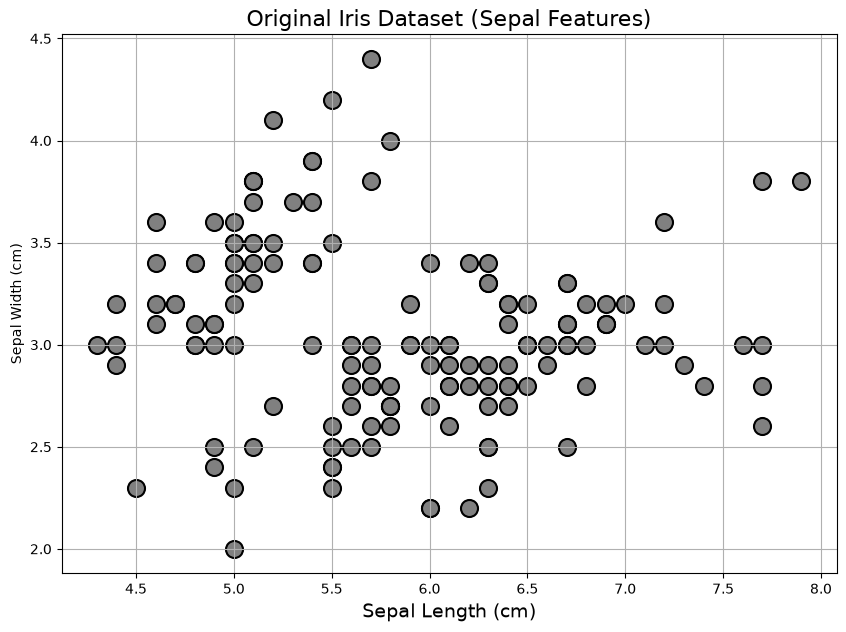

In [9]:
# plotting the original dataset

plt.figure(figsize=(10, 7))
sns.scatterplot(x=df['sepal length (cm)'], y=df['sepal width (cm)'], 
                color='gray', s=150, edgecolor='black', linewidth=1.5)
plt.title('Original Iris Dataset (Sepal Features)', fontsize=16)
plt.xlabel('Sepal Length (cm)', fontsize=14)
plt.ylabel('Sepal Width (cm)')
plt.grid(True)
plt.show()

# 2. Standardize the data using StandardScaler

In [12]:
df['target'] = iris_dataset.target

scaler = StandardScaler()

df_scaled = scaler.fit_transform(df.drop('target', axis=1))

print("Means:", df_scaled.mean(axis=0).round(2))
print("Std devs:", df_scaled.std(axis=0).round(2))

Means: [-0. -0. -0. -0.]
Std devs: [1. 1. 1. 1.]


**StandardScaler rescales each feature to a mean of 0 and standard deviation of 1**

# 3. Apply K-Means Clustering 

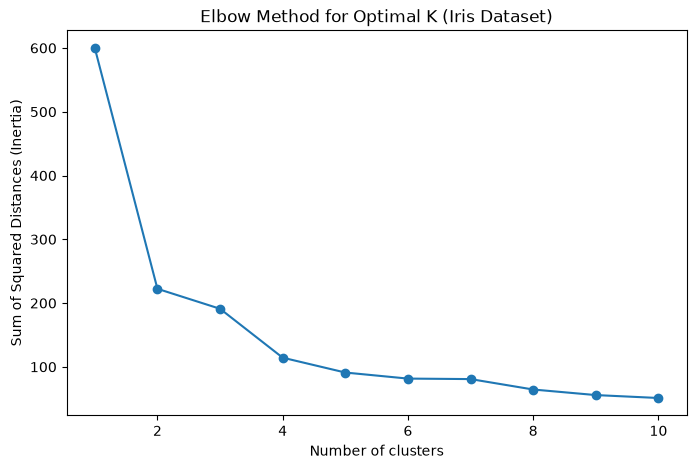

In [13]:
sse_iris = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    sse_iris.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), sse_iris, marker='o')
plt.title('Elbow Method for Optimal K (Iris Dataset)')
plt.xlabel('Number of clusters')
plt.ylabel('Sum of Squared Distances (Inertia)')
plt.show()

**Beyond $k = 3$, reductions in SSE are not as pronounced compared to the sharp drop from $k = 1$ to $k = 2$. Therefore, $k = 3$ is chosen because it balances inertia reduction with the dataset's underlying structure of 3 biological species**

In [16]:
kmeans_iris = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans_iris.fit_predict(df_scaled)

# 4. Visualize the clusters

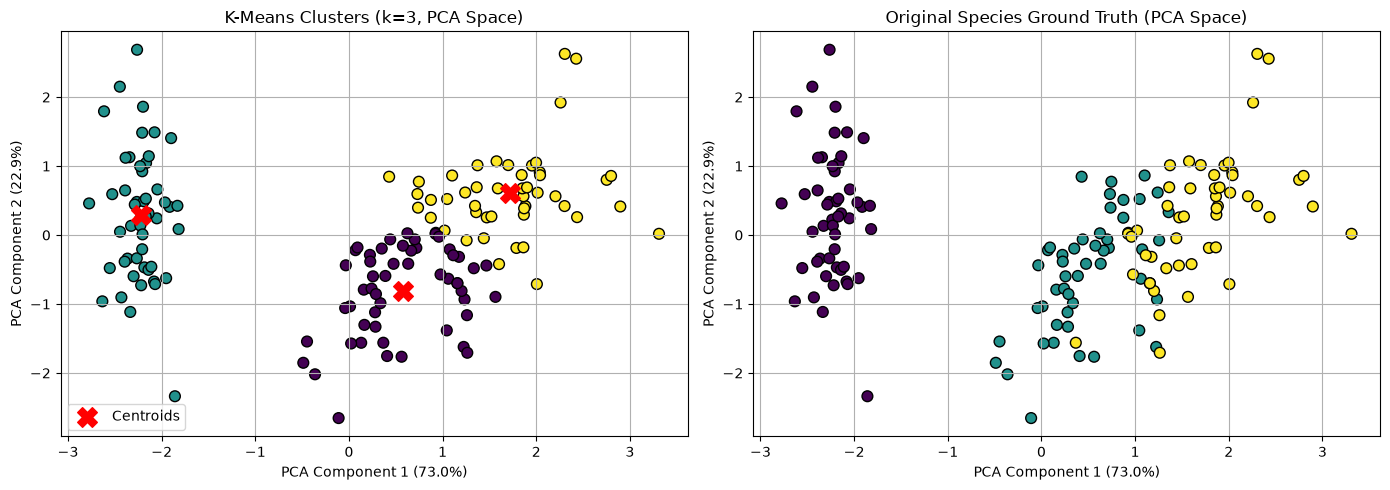

In [18]:
pca = PCA(n_components=2)
x_pca = pca.fit_transform(df_scaled)

centroids_pca = pca.transform(kmeans_iris.cluster_centers_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# For the left side
axes[0].scatter(x_pca[:, 0], x_pca[:, 1], c=df['cluster'], cmap='viridis', edgecolors='k', s=60)
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='red', marker='X', s=200, label='Centroids')
axes[0].set_title('K-Means Clusters (k=3, PCA Space)')
axes[0].set_xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend()
axes[0].grid(True)

# For the right side
axes[1].scatter(x_pca[:, 0], x_pca[:, 1], c=df['target'], cmap='viridis', edgecolors='k', s=60)
axes[1].set_title('Original Species Ground Truth (PCA Space)')
axes[1].set_xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

# 5. Interpret The Results

In [19]:
# 5. Interpret the Results: Compare Clusters with Original Species
actual_species = pd.Categorical.from_codes(df['target'], iris_dataset.target_names)

# Contingency table (cross-tabulation)
contingency_matrix = pd.crosstab(
    actual_species,
    df['cluster'],
    rownames=['Actual Species'],
    colnames=['Assigned Cluster']
)

print("Contingency Table:")
display(contingency_matrix)

# Calculate Cluster Purity: (Sum of maximum class counts per cluster column) / total samples
purity_score = np.sum(np.amax(contingency_matrix.to_numpy(), axis=0)) / float(len(df))
print(f"\nOverall Cluster Purity: {purity_score * 100:.2f}%")

Contingency Table:


Assigned Cluster,0,1,2
Actual Species,,,
setosa,0,50,0
versicolor,39,0,11
virginica,14,0,36



Overall Cluster Purity: 83.33%


# Own Interpretations
* The iris species, setosa, was correctly classified to its cluster
* Versicolor and virginica had a minor overlap, but the majority of samples were correctly grouped into their dominant clusters, resulting in an overall cluster purity of 83.33%

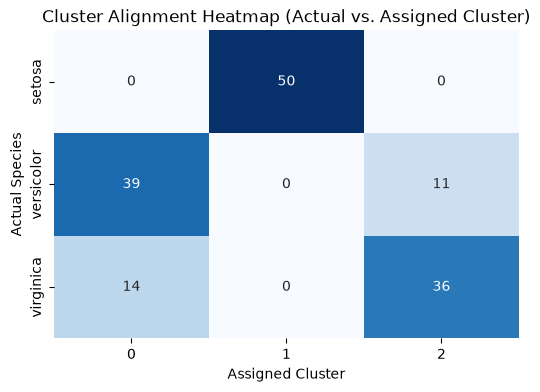

In [61]:
# Visualize alignment with a styled heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(contingency_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Cluster Alignment Heatmap (Actual vs. Assigned Cluster)')
plt.show()

# Questions to Answer:

## 1. What is the ideal k for this clustering project?
* **Metric Evaluation (Elbow Method):** 
  The most substantial drop occurs between $k = 1$ and $k = 2$, with a distinct inflection point leveling off at $k = 3$. Beyond $k = 3$, further increases in $k$ yield diminishing returns.
* **Selection Justification:** 
  **$k = 3$ is the ideal choice.** While $k = 2$ mathematically demonstrates high separation due to the isolated nature of Setosa, choosing $k = 3$ balances inertia stabilization within the 3 species found in the dataset.

## 2. How well do the clusters align with the original species in the dataset?

* **Alignment Breakdown:**
  * **Iris-setosa:** Achieves **100% alignment** (all 50 samples isolate into a single dedicated cluster with zero misassignments). This is because *setosa* is linearly separable with distinctly smaller petal dimensions.
  * **Iris-versicolor & Iris-virginica:** Exhibit showed minor overlap because their petal and sepal measurements partially overlap in continuous feature space, K-Means misallocates roughly 10 to 15 border flowers between these two clusters.
* **Cluster Purity:**
  * Based on the contingency matrix, the clustering achieves an overall **cluster purity of approximately 83.33%**, demonstrating that unsupervised spatial distance closely reconstructs natural botanical classifications.

## 3. What challenges or limitations did you encounter while clustering?
* When trying to save the predicted clusters back into our DataFrame, we kept accidentally feeding the new 'Cluster' or 'target' columns back into the scaler and PCA. This threw ValueError dimension errors because the model suddenly expected more features than the 4 measurements we started with. We had to make sure we isolated only the 4 numerical feature columns before scaling.
* I expected K-Means cluster 0 to automatically match target label 0 (setosa). I got confused when the numbers didn't align or when a standard confusion matrix gave strange results. I had to learn that K-Means assigns cluster IDs arbitrarily based on whichever random centroid got picked first, so we have to cross-tabulate the data to see which cluster actually represents which flower.
* In class examples, the elbow method usually shows a sharp, obvious bend. On the Iris dataset, however, the graph bent strongly at $k = 2$ and had a much softer curve at $k = 3$. It was challenging to decide whether to trust the mathematical metric ($k = 2$) or the known domain knowledge of the 3 biological species ($k = 3$).
